In [ ]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import cv2
import numpy as np
from PIL import Image
from sqlalchemy import create_engine

# 폰트 설정
font_path = 'C:\Windows\Fonts\gulim.ttc' 
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()

In [19]:
# DB 연결 정보 설정
DB_USER = 'farmorai_admin'
DB_PASSWORD = 'farmorai12345'
DB_HOST = '192.168.0.4'  # 또는 특정 IP
DB_PORT = '3306'         # 포트 번호
DB_NAME = 'farmdb'

# SQLAlchemy 엔진 생성
engine = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# SQL 쿼리 작성 및 DataFrame으로 변환
sql = "SELECT * FROM apple_label_dataset"
df = pd.read_sql(sql, engine)

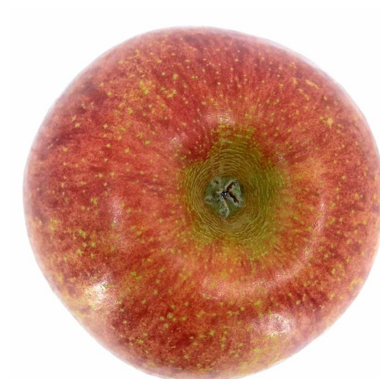

In [20]:
zip_file_path = '../../apple_data/image_data.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
   image_file_name = df['file_name'][0]
   
   with zip_ref.open(image_file_name) as img_file:
      image = Image.open(img_file)

      plt.imshow(image)
      plt.axis('off')
      plt.show()

In [21]:
zip_file_path = '../../apple_data/image_data.zip'
img_data = []
label_to_names = {'특':0, '상':1, '보통':2}
label_data = []

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
   for _, file in df.iterrows():
      with zip_ref.open(file['file_name']) as img_file:
         # 이미지 파일을 ByteIO로 읽어와 OpenCV로 읽기
         img_bytes = img_file.read()
         img_array = np.frombuffer(img_bytes, np.uint8)
         image = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

         # 이미지 리사이징 (224 x 224 크기로 리사이징)
         resized_img = cv2.resize(image, (224, 224))

         # 이미지 데이터와 레이블 데이터 추가
         img_data.append(resized_img)
         label_name = label_to_names.get(file['cate3'])
         label_data.append(label_name)

# 리스트를 numpy 배열로 변환
img_data_array = np.array(img_data)
label_data_array = np.array(label_data)

# 파일로 저장
np.save('apple_images.npy', img_data_array)
np.save('apple_labels.npy', label_data_array)

print(f'이미지 데이터 저장 완료: {img_data_array.shape}')
print(f'레이블 데이터 저장 완료: {label_data_array.shape}')

이미지 데이터 저장 완료: (1564, 224, 224, 3)
레이블 데이터 저장 완료: (1564,)


In [ ]:
df_main = pd.DataFrame({'image': img_data, 'label': label_data})
df_main.to_sql('apple_main_dataset', con=engine, if_exists='replace', index=False)

1564